In [62]:
import glob
import torch
import warnings
import numpy as np
import pop_tools
import xesmf as xe
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from engression.models import Net
from engression import engression
from dask.distributed import Client

In [2]:
# ------------------------------
# Settings
# ------------------------------

# Set seed
torch.manual_seed(0)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ignore port warning
warnings.filterwarnings("ignore", message="Port 8787 is already in use")

# Load grids
low_grid = pop_tools.get_grid('POP_gx1v7')
low_grid['TAREA'] = low_grid['TAREA'] / 1e4
low_grid['TAREA'].attrs['units'] = 'm^2'

high_grid = xr.open_dataset('/glade/p/cesmdata/cseg/inputdata/share/domains/domain.ocn.tx0.1v2.161014.nc')
high_grid['tarea'] = high_grid['area'] / 1e4
high_grid['tarea'].attrs['units'] = 'm^2'

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 200)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Plotting
cmap = plt.colormaps['Blues']
plt.rcParams["figure.figsize"] = [6, 6]

# Files
low_res_dirs = sorted(glob.glob('/gdex/data/d651030/BHIST/*ihesp-hires*'))
high_res_dirs = sorted(glob.glob('/gdex/data/d651007/*ihesp-hires*'))

low_vars = ['hi_d', 'SST', 'TAUX', 'TAUY', 'Tsfc_d']
target_var = 'hi_d'

bbox = {"lon_min": -115, "lon_max": -95, "lat_min": 66, "lat_max": 73}
lon_min = -115 % 360
lon_max = -95 % 360

comp_map = {
    'SST': 'ocn',
    'TAUX': 'ocn',
    'TAUY': 'ocn',
    'hi_d': 'ice',
    'Tsfc_d': 'ice'
}

# Set up client
client = Client(n_workers=1, threads_per_worker=8, memory_limit='120GB')
print("If on NCAR, copy and paste this link into the Dask Dashboard tab:")
print(client.dashboard_link)
print("\nDevice:", device)

If on NCAR, copy and paste this link into the Dask Dashboard tab:
https://jupyterhub.hpc.ucar.edu/stable/user/skygale/proxy/8787/status


## Set up training and testing data

In [3]:
# ------------------------------
# File Collection
# ------------------------------
def collect_files(dirs, vars, comp_lookup=None):
    out = []
    for d in dirs:
        member_files = {}
        for v in vars:
            comp = comp_lookup[v] if comp_lookup else 'ice'
            pattern = f"{d}/{comp}/proc/tseries/day_1/*{v}*.nc"
            member_files[v] = sorted(glob.glob(pattern))
        out.append(member_files)
    return out


low_res_files = collect_files(low_res_dirs, low_vars, comp_map)
high_res_files = collect_files(high_res_dirs, [target_var])

print('Low-res  | # ensembles:', len(low_res_files), '| # variables:', len(low_res_files[0]))
print('High-res | # ensembles:', len(high_res_files), '| # variables:', len(high_res_files[0]))

Low-res  | # ensembles: 9 | # variables: 5
High-res | # ensembles: 9 | # variables: 1


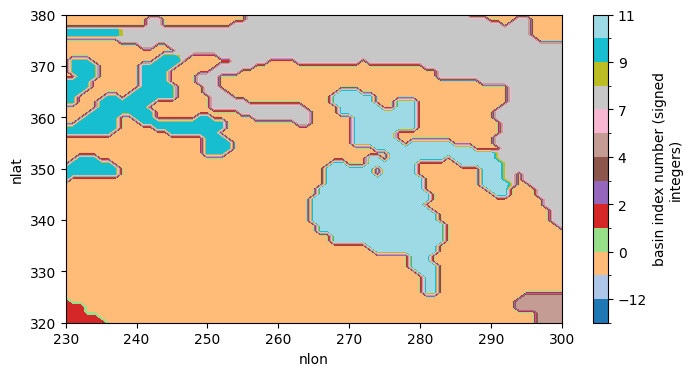

In [4]:
regions = np.array(np.unique(low_grid.REGION_MASK))

plt.figure(figsize=(8, 4))
low_grid.REGION_MASK.plot.contourf(levels=regions, cmap='tab20')
plt.xlim(230, 300)
plt.ylim(320, 380)
plt.show()

In [5]:
# ------------------------------
# Extraction Function
# ------------------------------
def extract_vector(file_list, varname):

    # Open last file lazily
    ds = xr.open_dataset(file_list[-1], decode_timedelta=True)

    # Merge POP grid
    if varname in ['hi_d', 'Tsfc_d']:
        da = xr.merge(
            [
                ds[varname].drop_vars(['TLAT', 'TLON', 'ULAT', 'ULON']),
                low_grid[['TLAT', 'TLONG', 'TAREA']].rename_dims({'nlat': 'nj', 'nlon': 'ni'})
            ],
            compat='override',
            combine_attrs='no_conflicts'
        )

        region = low_grid['REGION_MASK'].rename({'nlat': 'nj', 'nlon': 'ni'})

    if varname in ['SST', 'TAUX', 'TAUY']:
        da = xr.merge(
            [
                ds[varname].drop_vars(['TLAT', 'TLONG', 'ULAT', 'ULONG']),
                low_grid[['TLAT', 'TLONG', 'TAREA']]
            ],
            compat='override',
            combine_attrs='no_conflicts'
        )

        region = low_grid[['REGION_MASK']]

    # Select last day
    da_sel = da[varname].isel(time=-1)

    # Curvilinear mask using TLAT/TLONG
    mask = (
        (da['TLAT'] >= bbox["lat_min"]) &
        (da['TLAT'] <= bbox["lat_max"]) &
        (da['TLONG'] >= lon_min) &
        (da['TLONG'] <= lon_max)
    )

    da_masked = da_sel.where(mask, drop=True)

    # Land mask
    region_mask = region.where(mask, drop=True)
    land_mask = (region_mask == 0).astype(float).values
    arr = np.nan_to_num(da_masked.values, nan=0.0)

    return arr, land_mask


# ------------------------------
# Build X (Low-Res Predictors)
# ------------------------------

X_list = []

for i, member in enumerate(low_res_files):

    member_stack = []
    land_mask_channel = None

    for var in low_vars:

        vec, land_mask = extract_vector(member[var], var)
        member_stack.append(vec)

        if land_mask_channel is None:
            land_mask_channel = land_mask

    # Stack physical variables
    member_concat = np.stack(member_stack, axis=0)

    # Add land mask as extra channel
    member_concat = np.concatenate(
        [member_concat, land_mask_channel[None, :, :]],
        axis=0
    )

    X_list.append(member_concat)
    print(f"--> Finished Ensemble #{i+1}")

X = np.stack(X_list, axis=0)
print("Final X shape:", X.shape)

--> Finished Ensemble #1
--> Finished Ensemble #2
--> Finished Ensemble #3
--> Finished Ensemble #4
--> Finished Ensemble #5
--> Finished Ensemble #6
--> Finished Ensemble #7
--> Finished Ensemble #8
--> Finished Ensemble #9
Final X shape: (9, 6, 19, 26)


In [6]:
# ------------------------------
# Extraction Function
# ------------------------------
def extract_vector_hires(file_list, varname):

    # Open last file lazily
    ds = xr.open_dataset(file_list[-1], decode_timedelta=True)

    # Merge POP grid
    da = xr.merge(
        [
            ds[varname].drop_vars(['TLAT', 'TLON', 'ULAT', 'ULON']),
            high_grid[['xc', 'yc', 'tarea']]
        ],
        compat='override',
        combine_attrs='no_conflicts'
    )

    # Select last day
    da_sel = da[varname].isel(time=-1)

    # Curvilinear mask using xc/yc
    mask = (
        (da['yc'] >= bbox["lat_min"]) &
        (da['yc'] <= bbox["lat_max"]) &
        (da['xc'] >= lon_min) &
        (da['xc'] <= lon_max)
    )

    da_masked = da_sel.where(mask, drop=True)
    Y_mask = high_grid['mask'].where(mask, drop=True)
    Y_land_mask = (Y_mask == 0).astype(float).values
    arr = np.nan_to_num(da_masked.values, nan=0.0)

    return arr, Y_land_mask

# ------------------------------
# Build Y (High-Res Target)
# ------------------------------

Y_list = []

for i, member in enumerate(high_res_files):

    vec, Y_land_mask = extract_vector_hires(member[target_var], target_var)
    Y_list.append(vec)

    print(f"--> Finished Ensemble #{i+1}")

Y = np.stack(Y_list, axis=0)
Y = Y[:, np.newaxis, :, :]

print("Final Y shape:", Y.shape)
print("Y_land_mask shape:", Y_land_mask.shape)

--> Finished Ensemble #1
--> Finished Ensemble #2
--> Finished Ensemble #3
--> Finished Ensemble #4
--> Finished Ensemble #5
--> Finished Ensemble #6
--> Finished Ensemble #7
--> Finished Ensemble #8
--> Finished Ensemble #9
Final Y shape: (9, 1, 207, 460)
Y_land_mask shape: (207, 460)


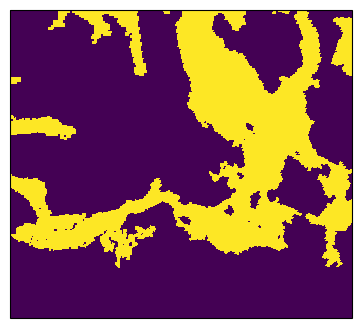

In [7]:
# Cambridge Bay bounding box
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal(central_longitude=-105, central_latitude=69))
ax.set_extent([-115, -95, 66, 73], crs=ccrs.PlateCarree())
ax.pcolormesh(high_grid['xc'], high_grid['yc'], high_grid.mask.values, transform=ccrs.PlateCarree())
plt.show()

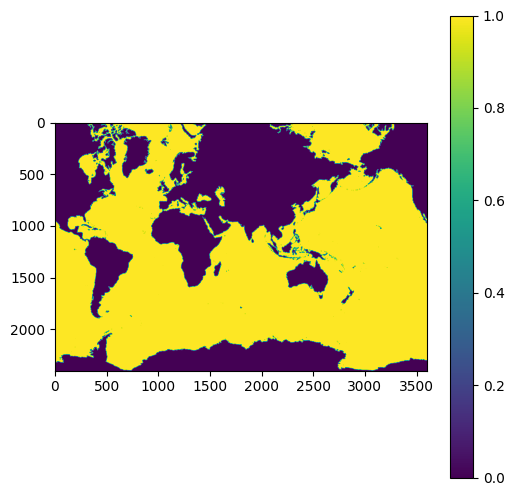

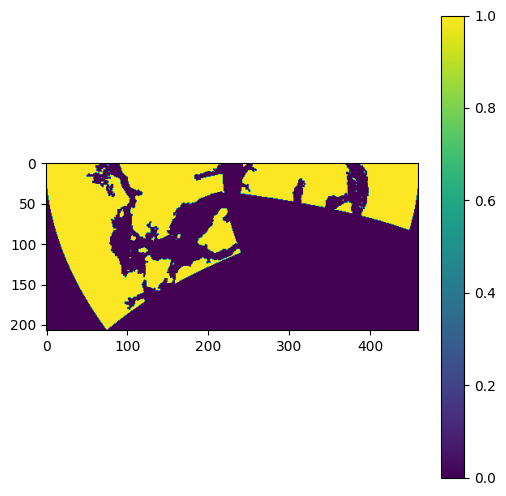

In [8]:
plt.figure()
plt.imshow(high_grid.mask.values[::-1])
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(Y_land_mask[::-1])
plt.colorbar()
plt.show()

## Engression Model

In [9]:
# ------------------------------
# Set up regridding
# ------------------------------
TLONG = ((low_grid.TLONG + 180) % 360) - 180

# Mask grids
mask = (
    (TLONG >= bbox["lon_min"]) &
    (TLONG <= bbox["lon_max"]) &
    (low_grid.TLAT >= bbox["lat_min"]) &
    (low_grid.TLAT <= bbox["lat_max"])
)
low_grid_sub = low_grid.where(mask, drop=True)

mask_high = (
    (high_grid.xc >= lon_min) &
    (high_grid.xc <= lon_max) &
    (high_grid.yc >= bbox["lat_min"]) &
    (high_grid.yc <= bbox["lat_max"])
)
high_grid_sub = high_grid.where(mask_high, drop=True)

# Source grid
ds_src = xr.Dataset({
    "lat": (("nlat", "nlon"), low_grid_sub.TLAT.values),
    "lon": (("nlat", "nlon"), TLONG.where(mask, drop=True).values),
})

# Destination grid
ds_dst = xr.Dataset({
    "lat": (("nj", "ni"), high_grid_sub.yc.values),
    "lon": (("nj", "ni"), high_grid_sub.xc.values),
})

# Create regridders
# Continuous
regridder_bilinear = xe.Regridder(
    ds_src,
    ds_dst,
    method="bilinear",
    periodic=False
)

# Land mask
regridder_nearest = xe.Regridder(
    ds_src,
    ds_dst,
    method="nearest_s2d"
)

# ------------------------------
# Interpolation
# ------------------------------
X_interp_list = []

for m in range(X.shape[0]):

    member_channels = []

    # Continuous predictors
    for i in range(5):
        da = xr.DataArray(
            X[m, i],
            dims=("nlat", "nlon")
        )
        da_interp = regridder_bilinear(da)
        member_channels.append(da_interp.values)

    # Land mask (nearest)
    da_land = xr.DataArray(
        X[m, 5],
        dims=("nlat", "nlon")
    )
    land_interp = regridder_nearest(da_land)
    member_channels.append(land_interp.values)

    member_stack = np.stack(member_channels, axis=0)
    X_interp_list.append(member_stack)

X_hr = np.stack(X_interp_list, axis=0)[:, :5]  # drop land channel for now

print("X_hr shape:", X_hr.shape)

X_hr shape: (9, 5, 207, 460)


In [14]:
# Flatten
N_ens, C, H, W = X_hr.shape
X_flat = X_hr.reshape(N_ens, C, -1)
Y_flat = Y.reshape(N_ens, 1, -1)

# Mask
ocean_mask = (high_grid_sub.mask.values == 1)
ocean_flat = ocean_mask.flatten()
X_flat = X_flat[:, :, ocean_flat]
Y_flat = Y_flat[:, :, ocean_flat]

# Split by ensemble member
n_ens = X_flat.shape[0]
C = X_flat.shape[1]

test_member = np.random.choice(n_ens)
train_members = [i for i in range(n_ens) if i != test_member]

print("Test member:", test_member)

# Reshape
X_train_np = (X_flat[train_members].transpose(0, 2, 1).reshape(-1, C))
Y_train_np = (Y_flat[train_members].transpose(0, 2, 1).reshape(-1, 1))
X_test_np = X_flat[test_member].T
Y_test_np = Y_flat[test_member].T

# Standardize (TRAINING STATS ONLY)
X_mean = X_train_np.mean(axis=0)
X_std = X_train_np.std(axis=0)
X_std[X_std == 0] = 1.0
X_train_np = (X_train_np - X_mean) / X_std
X_test_np = (X_test_np - X_mean) / X_std

print("X_train:", X_train_np.shape)
print("Y_train:", Y_train_np.shape)
print("X_test :", X_test_np.shape)
print("Y_test :", Y_test_np.shape)

Test member: 3
X_train: (97840, 5)
Y_train: (97840, 1)
X_test : (12230, 5)
Y_test : (12230, 1)


In [15]:
# Convert to torch and move to GPU
X_train = torch.tensor(X_train_np, dtype=torch.float32).to(device)
Y_train = torch.tensor(Y_train_np, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test_np, dtype=torch.float32).to(device)
Y_test = torch.tensor(Y_test_np, dtype=torch.float32).to(device)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: torch.Size([97840, 5])
Y_train: torch.Size([97840, 1])
X_test: torch.Size([12230, 5])
Y_test: torch.Size([12230, 1])


In [18]:
# Final checks
print(torch.isnan(X_train).sum())
print(torch.isnan(Y_train).sum())
print(X_train.mean(0))
print(X_train.std(0))

tensor(0)
tensor(0)
tensor([ 1.1977e-07, -4.9906e-09,  1.7467e-08, -2.4953e-09, -6.6126e-08])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [22]:
# Fit an engression model
engressor = engression(
    X_train,
    Y_train,
    lr=0.005,
    num_epochs=500,
    batch_size=2048,
    device=device
)

Running on CPU.

Data is standardized for training only; the printed training losses are on the standardized scale. 
However during evaluation, the predictions, evaluation metrics, and plots will be on the original scale.

Training based on mini-batch gradient descent with a batch size of 2048.
[Epoch 1 (0%), batch 47] energy-loss: 0.4654,  E(|Y-Yhat|): 0.8789,  E(|Yhat-Yhat'|): 0.8270
[Epoch 100 (20%), batch 47] energy-loss: 0.3810,  E(|Y-Yhat|): 0.7709,  E(|Yhat-Yhat'|): 0.7799
[Epoch 200 (40%), batch 47] energy-loss: 0.3728,  E(|Y-Yhat|): 0.7507,  E(|Yhat-Yhat'|): 0.7558
[Epoch 300 (60%), batch 47] energy-loss: 0.3726,  E(|Y-Yhat|): 0.7580,  E(|Yhat-Yhat'|): 0.7708
[Epoch 400 (80%), batch 47] energy-loss: 0.3648,  E(|Y-Yhat|): 0.7480,  E(|Yhat-Yhat'|): 0.7664
[Epoch 500 (100%), batch 47] energy-loss: 0.3654,  E(|Y-Yhat|): 0.7375,  E(|Yhat-Yhat'|): 0.7443

Training loss on the original (non-standardized) scale:
	Energy-loss: 0.3232,  E(|Y-Yhat|): 0.6576,  E(|Yhat-Yhat'|): 0.6688

Pre

In [23]:
engressor.summary()

Engression model with
	 number of layers: 2
	 hidden dimensions: 100
	 noise dimensions: 100
	 residual blocks: False
	 number of epochs: 500
	 batch size: 2048
	 learning rate: 0.005
	 standardization: True
	 training mode: False
	 device: cpu

Training loss (original scale):
	 energy-loss: 0.32, 
	E(|Y-Yhat|): 0.66, 
	E(|Yhat-Yhat'|): 0.67


In [28]:
# Evaluation
mse = engressor.eval_loss(X_test, Y_test, loss_type="l2")
print("L2 loss:", mse)
print("RMSE:", mse**0.5)

print(
    "correlation between predicted and true means:",
    engressor.eval_loss(X_test, Y_test, loss_type="cor")
)

L2 loss: 0.8069546222686768
RMSE: 0.898306530238246
correlation between predicted and true means: 0.34430399537086487


In [29]:
# Predictions
Y_pred_test = engressor.predict(X_test)

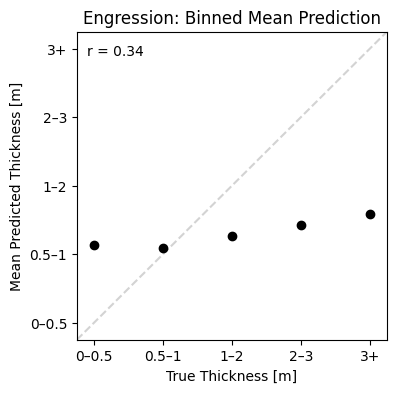

In [87]:
bin_centers = []
mean_pred = []

bins = [0, 0.5, 1.0, 2.0, 3.0, 10]  # meters
labels = ["0–0.5", "0.5–1", "1–2", "2–3", "3+"]

y_true = Y_test.cpu().numpy().flatten()
y_pred = Y_pred_test.detach().cpu().numpy().flatten()
true_cat = np.digitize(y_true, bins)
pred_cat = np.digitize(y_pred, bins)

for i in range(1, len(bins)):
    mask = (y_true >= bins[i-1]) & (y_true < bins[i])
    if np.sum(mask) > 0:
        bin_centers.append(np.mean(y_true[mask]))
        mean_pred.append(np.mean(y_pred[mask]))

plt.figure(figsize=(4, 4))
plt.plot([-0.25, 4.25], [-0.25, 4.25], color='lightgrey', linestyle='--')
plt.scatter(labels, mean_pred, color='k', marker="o", zorder=3)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.xlabel("True Thickness [m]")
plt.ylabel("Mean Predicted Thickness [m]")
plt.title("Engression: Binned Mean Prediction")
plt.text(-0.1, 3.9, "r = 0.34")
plt.xlim(-0.25, 4.25)
plt.ylim(-0.25, 4.25)
plt.show()

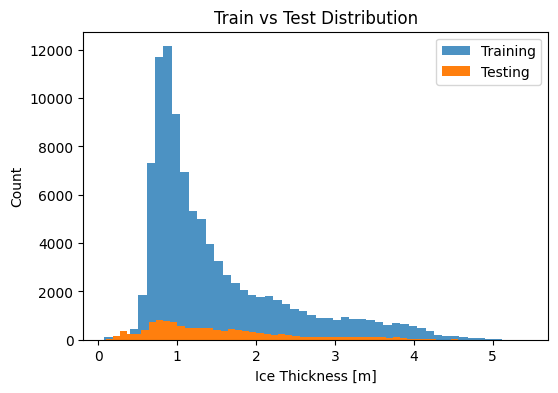

In [46]:
y_train = Y_train.cpu().numpy().flatten()

plt.figure(figsize=(6, 4))
plt.hist(y_train, bins=50, alpha=0.8, label="Training")
plt.hist(y_true, bins=50, label="Testing")
plt.xlabel("Ice Thickness [m]")
plt.ylabel("Count")
plt.legend()
plt.title("Train vs Test Distribution")
plt.show()

In [66]:
# Define model
num_features = X_train.shape[1]
model = Net(num_layer=2, hidden_dim=100, in_dim=num_features).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# Training loop (batched)
num_epochs = 500
batch_size = 2048
n_samples = X_train.shape[0]

for epoch in range(num_epochs):
    perm = torch.randperm(n_samples)
    for i in range(0, n_samples, batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train[idx]
        yb = Y_train[idx]

        opt.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        opt.step()

    if (epoch + 1) % 50 == 0:
        with torch.no_grad():
            train_loss = criterion(model(X_train), Y_train).item()
            test_loss = criterion(model(X_test), Y_test).item()
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

# Predictions
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train)
    y_pred_test = model(X_test)

rmse_test = torch.sqrt(criterion(y_pred_test, Y_test))
corr_test = np.corrcoef(Y_test.cpu().numpy().flatten(), y_pred_test.cpu().numpy().flatten())[0, 1]
print("Test RMSE:", rmse_test.item())
print("Test correlation:", corr_test)

Epoch 50/500 | Train Loss: 0.4220 | Test Loss: 0.7027
Epoch 100/500 | Train Loss: 0.4027 | Test Loss: 0.8073
Epoch 150/500 | Train Loss: 0.3791 | Test Loss: 0.8491
Epoch 200/500 | Train Loss: 0.3691 | Test Loss: 0.8336
Epoch 250/500 | Train Loss: 0.3597 | Test Loss: 0.8336
Epoch 300/500 | Train Loss: 0.3571 | Test Loss: 0.8411
Epoch 350/500 | Train Loss: 0.3530 | Test Loss: 0.8713
Epoch 400/500 | Train Loss: 0.3475 | Test Loss: 0.8832
Epoch 450/500 | Train Loss: 0.3533 | Test Loss: 0.9030
Epoch 500/500 | Train Loss: 0.3402 | Test Loss: 0.9396
Test RMSE: 0.9693542718887329
Test correlation: 0.19282535083396346


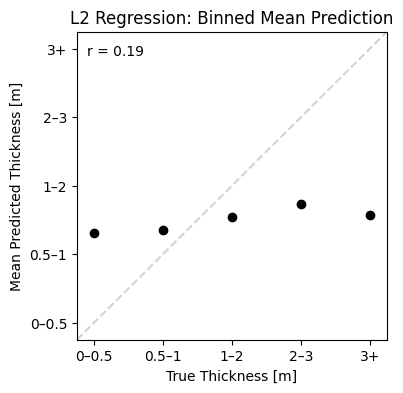

In [89]:
def plot_binned_predictions(y_true, y_pred, bins, labels):
    y_true = y_true.cpu().numpy().flatten()
    y_pred = y_pred.cpu().numpy().flatten()

    # Mean prediction per bin
    y_pred_mean = []
    for i in range(len(bins)-1):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        if mask.any():
            y_pred_mean.append(y_pred[mask].mean())
        else:
            y_pred_mean.append(np.nan)

    # Plot
    plt.figure(figsize=(4, 4))
    plt.plot([-0.25, 4.25], [-0.25, 4.25], color='lightgrey', linestyle='--')
    plt.scatter(labels, y_pred_mean, color="k", marker='o')
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.xlabel("True Thickness [m]")
    plt.ylabel("Mean Predicted Thickness [m]")
    plt.title("L2 Regression: Binned Mean Prediction")
    plt.text(-0.1, 3.9, "r = 0.19")
    plt.xlim(-0.25, 4.25)
    plt.ylim(-0.25, 4.25)
    plt.show()


bins = [0, 0.5, 1.0, 2.0, 3.0, 10]
labels = ["0–0.5", "0.5–1", "1–2", "2–3", "3+"]

plot_binned_predictions(Y_test, y_pred_test, bins, labels)

## Simple CNN

In [90]:
# ------------------------------
# Patch Extraction for Increased Samples
# low patch: 6 x 10 x 10
# high patch: 1 x 100 x 100 (10× upscaling)
# ------------------------------
def extract_patches(X, Y, low_patch_size=5, high_patch_size=53, stride=1):
    patches_X, patches_Y = [], []
    N, C, H, W = X.shape
    _, _, Hh, Wh = Y.shape

    for n in range(N):
        for i in range(0, H - low_patch_size + 1, stride):
            for j in range(0, W - low_patch_size + 1, stride):
                x_patch = X[n, :, i:i+low_patch_size, j:j+low_patch_size]

                # Compute corresponding high-res patch
                scale_i = i * Hh // H
                scale_j = j * Wh // W
                x_hi = low_patch_size * Hh // H
                y_hi = low_patch_size * Wh // W
                y_patch = Y[n, :, scale_i:scale_i+x_hi, scale_j:scale_j+y_hi]

                patches_X.append(x_patch)
                patches_Y.append(y_patch)

    return torch.stack(patches_X), torch.stack(patches_Y)


# ------------------------------
# Simple Super-Resolution CNN
# Input: (batch, 6, 10, 10)
# Conv layers: 2–3 layers, small kernels (3x3)
# Upsample layer: nn.Upsample(scale_factor=10, mode='bilinear', align_corners=False)
# Output: (batch, 1, 100, 100)
# ------------------------------
class SuperResCNN(nn.Module):
    def __init__(self, in_channels=6, out_channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 32, 3, padding=1)
        self.conv4 = nn.Conv2d(32, out_channels, 3, padding=1)
        self.relu = nn.ReLU()
        # self.upsample = nn.Upsample(size=(207, 460), mode='bilinear', align_corners=False)

    def forward(self, x, up_size=None):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.conv4(x)
        if up_size is not None:
            x = F.interpolate(x, size=up_size, mode='bilinear', align_corners=False)
        return x

In [91]:
# ------------------------------
# Prepare training data
# ------------------------------
X_tensor = torch.tensor(X).float()
Y_tensor = torch.tensor(Y).float()

# Channel-wise normalization
X_mean = X_tensor.mean(dim=(0, 2, 3), keepdim=True)
X_std = X_tensor.std(dim=(0, 2, 3), keepdim=True)
X_tensor = (X_tensor - X_mean) / X_std

# Extract patches (stride=1 for maximum data, adjust as needed)
X_patches, Y_patches = extract_patches(X_tensor, Y_tensor, low_patch_size=5, stride=1)
print("Patch shapes:", X_patches.shape, Y_patches.shape)

Patch shapes: torch.Size([2970, 6, 5, 5]) torch.Size([2970, 1, 54, 88])


In [96]:
# ------------------------------
# Train / test split
# ------------------------------
num_samples = X_patches.shape[0]
idx = np.arange(num_samples)
np.random.shuffle(idx)

split = int(num_samples * 0.9)
train_idx = idx[:split]
test_idx = idx[split:]

X_train, Y_train = X_patches[train_idx], Y_patches[train_idx]
X_test, Y_test = X_patches[test_idx], Y_patches[test_idx]

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_test:", X_test.shape, "Y_test:", Y_test.shape)

X_train: torch.Size([2673, 6, 5, 5]) Y_train: torch.Size([2673, 1, 54, 88])
X_test: torch.Size([297, 6, 5, 5]) Y_test: torch.Size([297, 1, 54, 88])


In [93]:
# ------------------------------
# Initialize model, optimizer, loss
# ------------------------------
model = SuperResCNN()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [94]:
# ------------------------------
# Training loop for patch-based super-resolution
# Assume X_train, Y_train are patch tensors
# X_train: (num_patches, 6, low_H, low_W)
# Y_train: (num_patches, 1, high_H, high_W) -> high-res patch
# ------------------------------
num_epochs = 20
batch_size = 16

for epoch in range(num_epochs):
    permutation = torch.randperm(X_train.size(0))
    epoch_loss = 0

    for i in range(0, X_train.size(0), batch_size):
        optimizer.zero_grad()
        indices = permutation[i:i+batch_size]
        batch_X, batch_Y = X_train[indices], Y_train[indices]

        # Determine high-res patch size dynamically
        up_size = (batch_Y.shape[2], batch_Y.shape[3])

        outputs = model(batch_X, up_size=up_size)
        loss = criterion(outputs, batch_Y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss /= X_train.size(0)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}")

IndexError: tuple index out of range

In [170]:
# ------------------------------
# Evaluation
# ------------------------------
model.eval()
with torch.no_grad():
    # Dynamically upsample each patch to its high-res size
    up_size = (Y_test.shape[2], Y_test.shape[3])
    Y_pred = model(X_test, up_size=up_size)

# MSE
mse = ((Y_pred - Y_test)**2).mean().item()
print("CNN Test MSE:", mse)


# Spatial correlation function
def spatial_corr(y_true, y_pred):
    y_true_flat = y_true.reshape(y_true.shape[0], -1)
    y_pred_flat = y_pred.reshape(y_pred.shape[0], -1)
    corrs = []
    for i in range(y_true.shape[0]):
        if np.std(y_true_flat[i]) > 0:  # skip constant patches
            corrs.append(np.corrcoef(y_true_flat[i], y_pred_flat[i])[0,1])
    return np.nanmean(corrs)  # ignore NaNs


# Convert to numpy
Y_test_np = Y_test.cpu().numpy() if torch.is_tensor(Y_test) else Y_test
Y_pred_np = Y_pred.cpu().numpy() if torch.is_tensor(Y_pred) else Y_pred

corr = spatial_corr(Y_test_np, Y_pred_np)
print("CNN Test spatial correlation:", corr)

CNN Test MSE: 0.2822853624820709
CNN Test spatial correlation: 0.4901016779669464


In [171]:
# ------------------------------
# Bilinear baseline
# ------------------------------
# Only use the first channel of X_test as input to bilinear upsampling
Y_bilinear = F.interpolate(X_test[:, 0:1], size=(Y_test.shape[2], Y_test.shape[3]),
                           mode='bilinear', align_corners=False)

mse_bilinear = ((Y_bilinear - Y_test)**2).mean().item()
print("Bilinear upsampling MSE:", mse_bilinear)

Bilinear upsampling MSE: 1.5026381015777588


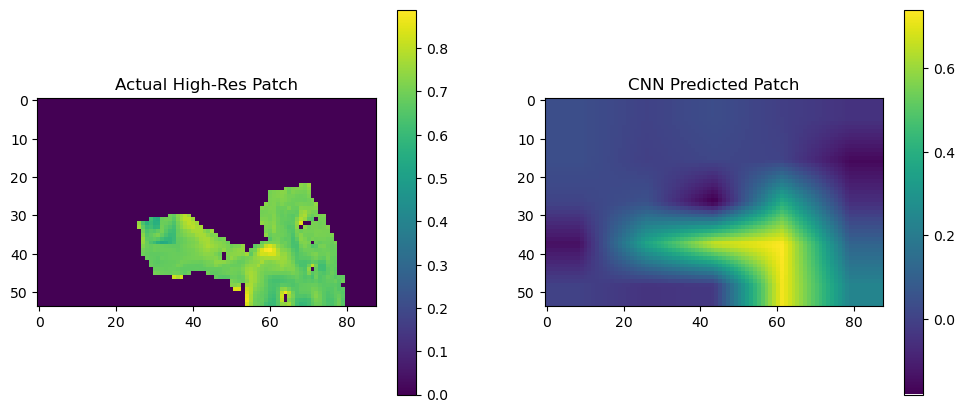

In [238]:
# ------------------------------
# Plot a random test patch vs prediction
# ------------------------------
sample_idx = np.random.randint(0, X_test.shape[0])
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(Y_test[sample_idx, 0].cpu().numpy(), cmap='viridis')
plt.title("Actual High-Res Patch")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(Y_pred[sample_idx, 0].cpu().numpy(), cmap='viridis')
plt.title("CNN Predicted Patch")
plt.colorbar()

plt.show()